In [72]:
import sys
sys.path.append('../modules')

In [73]:
from bsts import BSTSForCausalInferenceWrapper
from etl import *

import pandas as pd

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [74]:
ticker2permno = {
    "TSLA": 93436
}

In [75]:
# wrds_loader = WRDSLoader(username="farouk_b")
# wrds_loader.close()

Loading library list...
Done


In [76]:
# stocks = wrds_loader.download_stock_data(ticker2permno, from_="2010-01-01", to="2020-12-31", save_to="../data/stocks/")

In [81]:
stocks["TSLA"] = pd.read_csv("../data/stocks/TSLA_2010_2020.csv", index_col=0)
stocks["TSLA"] = preprocess_tsla(stocks["TSLA"])

In [ ]:
stocks_factors = ...

In [48]:
tweets = [("tweet_id", "2010-12-30", "text")] # mock tweet

In [43]:
pre_effect_lag_window  = 30 # days
post_effect_lag_window = 7  # days

models = {}
for ticker, stock_factors in stocks_factors.items():
    for tweet in tweets:
        tweet_id, tweet_date, _ = tweet
        models[tweet_id] = {}
        
        bsts_model = BSTSForCausalInferenceWrapper(data=stock_factors.astype(float))
        effect_lag = int(stock_factors.loc[stock_factors["date"] == tweet_date].index[0])
        bsts_model.fit(effect_lag, pre_effect_lag_window, post_effect_lag_window)
        
        models[tweet_id, ticker] = bsts_model

ValueError: data contains no exogenous variables

In [66]:
models["tweet_id"]["TSLA"].summary()

                                  Average         Cumulative
Actual                                  0                  0
Predicted                               0                  0
95% CI                             [0, 0]             [0, 0]
                                                            
Absolute Effect                         0                  0
95% CI                             [0, 0]             [0, 0]
                                                            
Relative Effect                   -110.3%            -110.3%
95% CI                  [-427.1%, 206.5%]  [-427.1%, 206.5%]
                                                            
P-value                             73.2%                   
Prob. of Causal Effect              26.8%                   
None


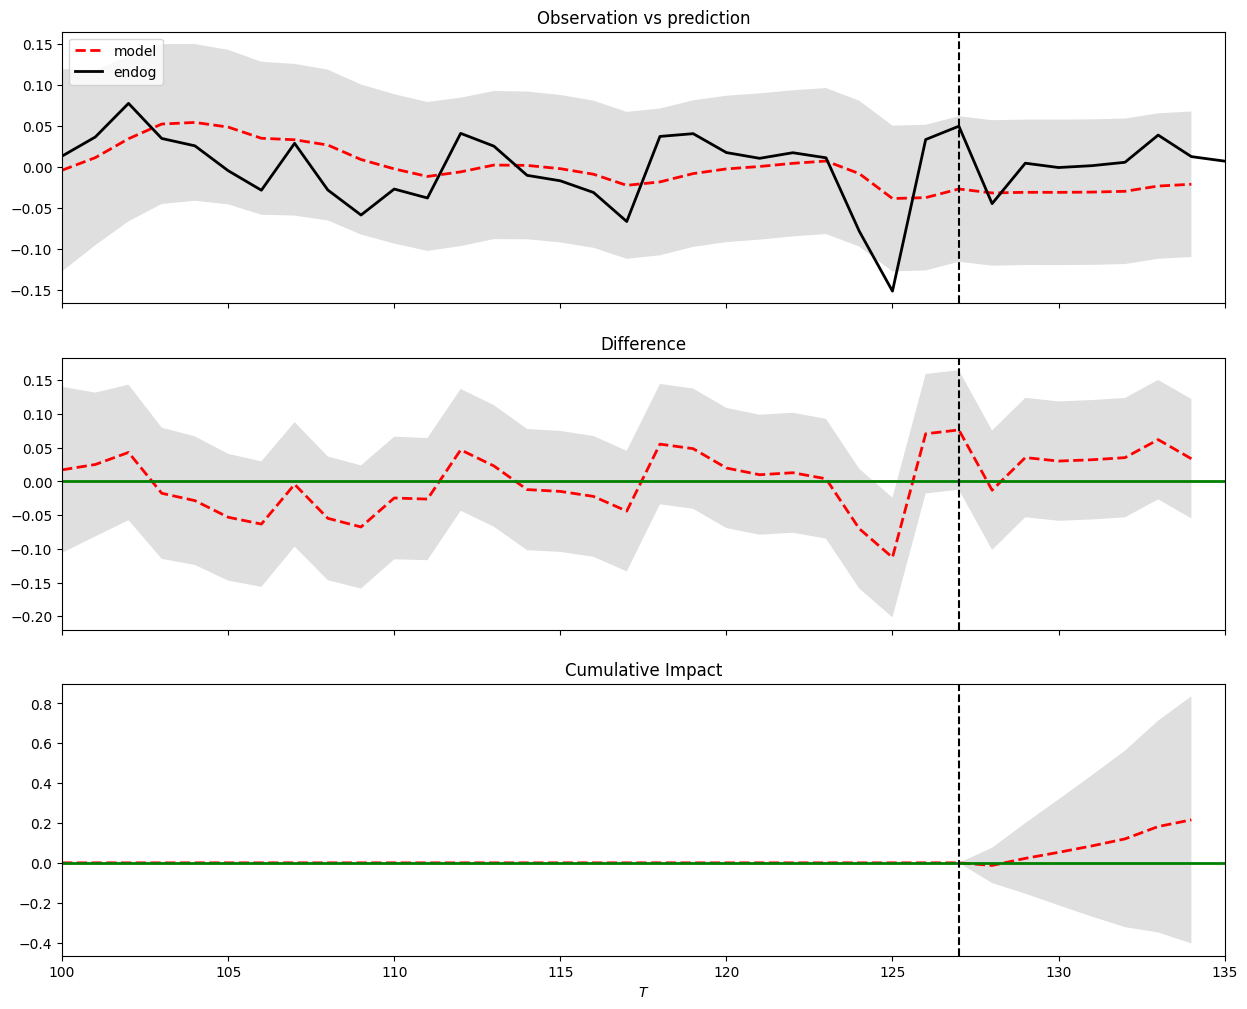

In [64]:
models["tweet_id"]["TSLA"].plot()